# 🛡️ Predictive Cash-Withdrawal & Cybercrime Analytics — EDA

This notebook loads the four merged datasets produced by `data_merge.py` and generates a comprehensive set of static, interactive, and geospatial visualizations.

**Libraries used:** `matplotlib`, `seaborn`, `plotly`, `hvplot`, `pygwalker`, `pydeck`, `folium`

**Portability notes (fixed vs. the original master notebook):**
- All data/output paths are resolved relative to the project root (or via `.env` overrides) — no hardcoded Windows drive letters.
- The India state-boundary GeoJSON used by the choropleth maps is a small, version-controlled file at `data/geo/india_states.geojson` — the notebook works fully offline (the original relied on a now-dead external gist URL).
- Heavy/optional cells (PyGWalker explorers) are gated behind an `ENABLE_HEAVY_CELLS` flag so the notebook can be smoke-tested quickly end-to-end.

---


In [1]:
# ─── CELL 1 — Master Imports & Configuration ────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Static & Statistical
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Interactive
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import hvplot.pandas  # activates .hvplot accessor on DataFrames

# Embedded Tableau-like explorer
import pygwalker as pyg

# Geospatial
import pydeck as pdk
import folium
from folium.plugins import HeatMap, MarkerCluster

# Load .env (if present) so paths / feature flags can be overridden without
# touching code. Safe no-op when python-dotenv isn't installed.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# ─── Plot aesthetics ───
sns.set_theme(style='whitegrid', palette='mako', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 110,
})

def _env(name, default):
    """os.getenv() that treats an unset OR blank ('') variable as 'not set'.

    A `.env.example`-derived `.env` ships with every key present but blank
    (e.g. `PROJECT_BASE_DIR=`), so plain os.getenv(name, default) would
    return '' instead of falling back to the sensible default.
    """
    val = os.getenv(name)
    return val if val else default


# ─── Portable data-directory resolution ───────────────────────────────────
# PROJECT_ROOT is the directory containing this notebook — works no matter
# where the repo is cloned to, on Windows, macOS, or Linux.
PROJECT_ROOT = _env('PROJECT_BASE_DIR', os.getcwd())

# Check current and legacy merged-data directory names/locations so the
# notebook keeps working regardless of which layout produced the CSVs.
_possible_dirs = [
    _env('MERGED_OUTPUT_DIR', None),
    os.path.join(PROJECT_ROOT, 'MERGED DATASETS'),
    os.path.join(PROJECT_ROOT, 'data', 'MERGED_DATASETS'),
    os.path.join(PROJECT_ROOT, '..', 'MERGED DATASETS'),
]
MERGED = next((d for d in _possible_dirs if d and os.path.exists(d)), os.path.join(PROJECT_ROOT, 'MERGED DATASETS'))

# Local, version-controlled India state-boundary GeoJSON (see data/geo/).
# Using a bundled file instead of a remote URL keeps the choropleth cells
# working offline and immune to link rot (the original gist URL is dead).
INDIA_GEOJSON_PATH = _env('INDIA_GEOJSON_PATH', os.path.join(PROJECT_ROOT, 'data', 'geo', 'india_states.geojson'))

# Optional heavy cells (PyGWalker interactive explorers) are skipped by
# default so the notebook can be smoke-tested quickly; set
# ENABLE_HEAVY_CELLS=1 in .env (or the shell) to render them.
ENABLE_HEAVY_CELLS = _env('ENABLE_HEAVY_CELLS', '0') == '1'

print(f'✅ All imports loaded.')
print(f'   MERGED datasets dir : {MERGED}')
print(f'   India GeoJSON path  : {INDIA_GEOJSON_PATH}')
print(f'   Heavy cells enabled : {ENABLE_HEAVY_CELLS}')


✅ All imports loaded.
   MERGED datasets dir : d:\Projects\CASHFLOW - COLLEGE\MERGED DATASETS
   India GeoJSON path  : d:\Projects\CASHFLOW - COLLEGE\data\geo\india_states.geojson
   Heavy cells enabled : False


In [2]:
# ─── CELL 2 — Load All Merged Datasets ──────────────────────────────────────
_required = {
    'merged_bank_financials.csv': 'bank_fin',
    'bank_transactions_clean.csv': 'txn',
    'merged_crime_data.csv': 'crime',
    'cyber_national_trends.csv': 'trends',
}
_missing = [f for f in _required if not os.path.exists(os.path.join(MERGED, f))]
if _missing:
    raise FileNotFoundError(
        f"Missing merged dataset file(s) in '{MERGED}': {_missing}. "
        "Run `python data_merge.py` first to (re)generate them from DATASETS/."
    )

bank_fin  = pd.read_csv(os.path.join(MERGED, 'merged_bank_financials.csv'))
txn       = pd.read_csv(os.path.join(MERGED, 'bank_transactions_clean.csv'),
                         parse_dates=['CustomerDOB', 'TransactionDate'])
crime     = pd.read_csv(os.path.join(MERGED, 'merged_crime_data.csv'))
trends    = pd.read_csv(os.path.join(MERGED, 'cyber_national_trends.csv'))

# Quick feature engineering on transactions
txn['TransactionHour'] = txn['TransactionTime'] // 10000   # HHMMSS → HH
txn['TransactionMonth'] = txn['TransactionDate'].dt.to_period('M').astype(str)
txn['TxnYear'] = txn['TransactionDate'].dt.year

print(f'bank_fin:  {bank_fin.shape}')
print(f'txn:       {txn.shape}')
print(f'crime:     {crime.shape}')
print(f'trends:    {trends.shape}')


bank_fin:  (135, 24)
txn:       (1047732, 12)
crime:     (724, 21)
trends:    (6, 6)


---
## 📈 Part 1 — National Cyber-Crime Trend Analysis
Dataset: `cyber_national_trends.csv`


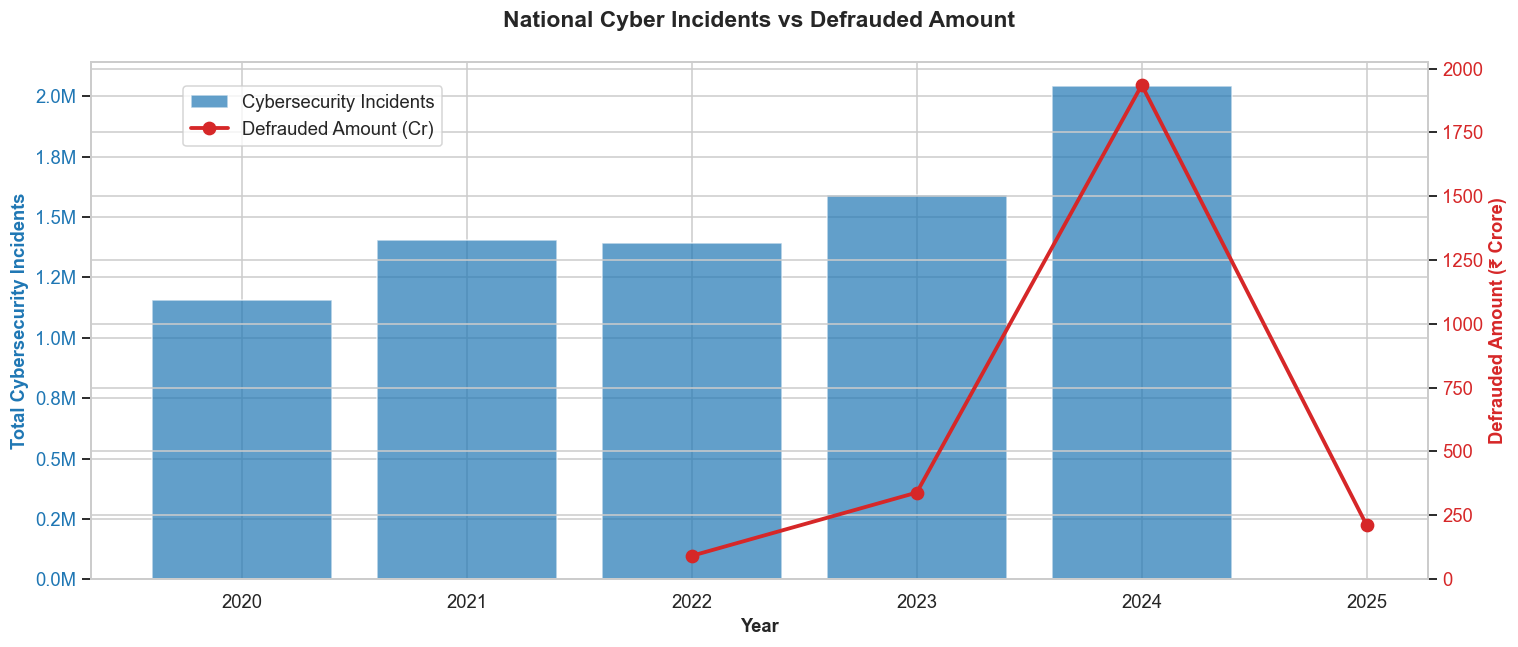

In [3]:
# ─── CELL 3 — Matplotlib: Dual-Axis National Cyber Trends ───────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#1f77b4'
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Cybersecurity Incidents', color=color1, fontsize=12, fontweight='bold')

# Strict masking to eliminate shape mismatch:
df_incidents = trends.dropna(subset=['Year', 'Cybersecurity_Incidents_Total']).sort_values('Year')
ax1.bar(
    df_incidents['Year'].astype(int),
    df_incidents['Cybersecurity_Incidents_Total'],
    color=color1,
    alpha=0.7,
    label='Cybersecurity Incidents'
)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('Defrauded Amount (₹ Crore)', color=color2, fontsize=12, fontweight='bold')

df_defrauded = trends.dropna(subset=['Year', 'Cyber_Fraud_Defrauded_Cr']).sort_values('Year')
ax2.plot(
    df_defrauded['Year'].astype(int),
    df_defrauded['Cyber_Fraud_Defrauded_Cr'],
    'o-',
    color=color2,
    linewidth=2.5,
    markersize=8,
    label='Defrauded Amount (Cr)'
)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('National Cyber Incidents vs Defrauded Amount', fontsize=15, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


In [4]:
# ─── CELL 4 — Plotly: Interactive Stacked Area – Cyber vs Financial Fraud ───
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Scatter(
    x=trends['Year'], y=trends['Cyber_Fraud_Incidents'],
    fill='tozeroy', name='Cyber Fraud Incidents',
    line=dict(color='#636EFA', width=2)), secondary_y=False)

fig.add_trace(go.Scatter(
    x=trends['Year'], y=trends['Financial_Fraud_Amount_Cr'],
    fill='tozeroy', name='Financial Fraud Amount (₹ Cr)',
    line=dict(color='#EF553B', width=2)), secondary_y=True)

fig.update_layout(
    title='Cyber Fraud Incidents vs Financial Fraud Amounts — National Trend',
    template='plotly_dark', height=500,
    hovermode='x unified')
fig.update_yaxes(title_text='Cyber Fraud Incidents', secondary_y=False)
fig.update_yaxes(title_text='Financial Fraud (₹ Cr)', secondary_y=True)
fig.show()


In [5]:
# ─── CELL 5 — hvPlot: Interactive Line – All National Trend Metrics ─────────
trends_melted = trends.melt(id_vars='Year', var_name='Metric', value_name='Value')
trends_melted.hvplot.line(
    x='Year', y='Value', by='Metric',
    width=900, height=450,
    title='National Cyber & Financial Fraud Metrics Over Time',
    line_width=2.5, legend='top_left')


:NdOverlay   [Metric]
   :Curve   [Year]   (Value)

---
## 🏦 Part 2 — Banking Financial Health & Infrastructure
Dataset: `merged_bank_financials.csv`


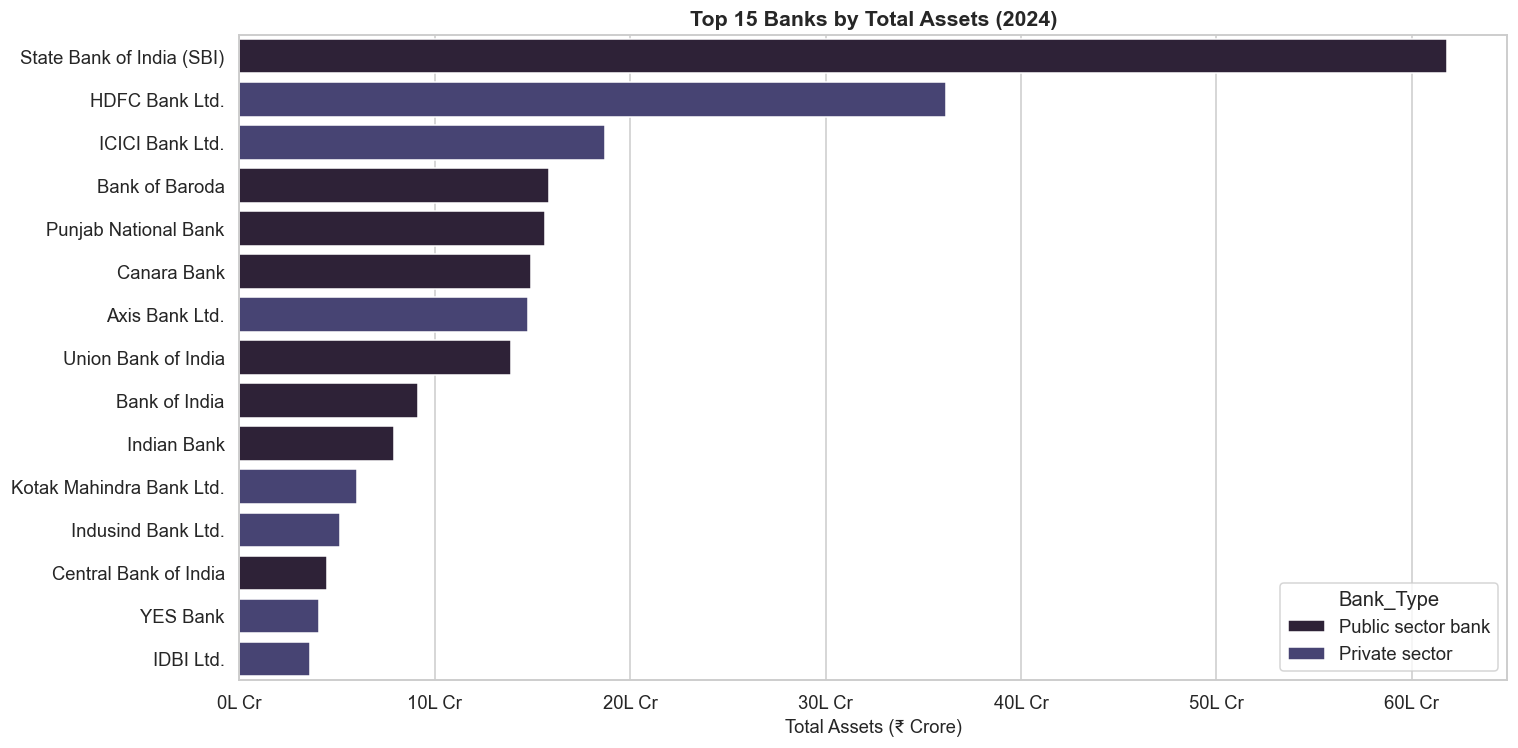

In [6]:
# ─── CELL 6 — Seaborn: Top 15 Banks by Total Assets (Latest Year) ──────────
latest = bank_fin[bank_fin['Year'] == bank_fin['Year'].max()]
top15_assets = latest.nlargest(15, 'Total_Assets_Cr')

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=top15_assets, y='Bank_Name', x='Total_Assets_Cr',
            hue='Bank_Type', dodge=False, ax=ax)
ax.set_title(f'Top 15 Banks by Total Assets ({top15_assets["Year"].iloc[0]})', fontweight='bold')
ax.set_xlabel('Total Assets (₹ Crore)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L Cr'))
plt.tight_layout()
plt.show()


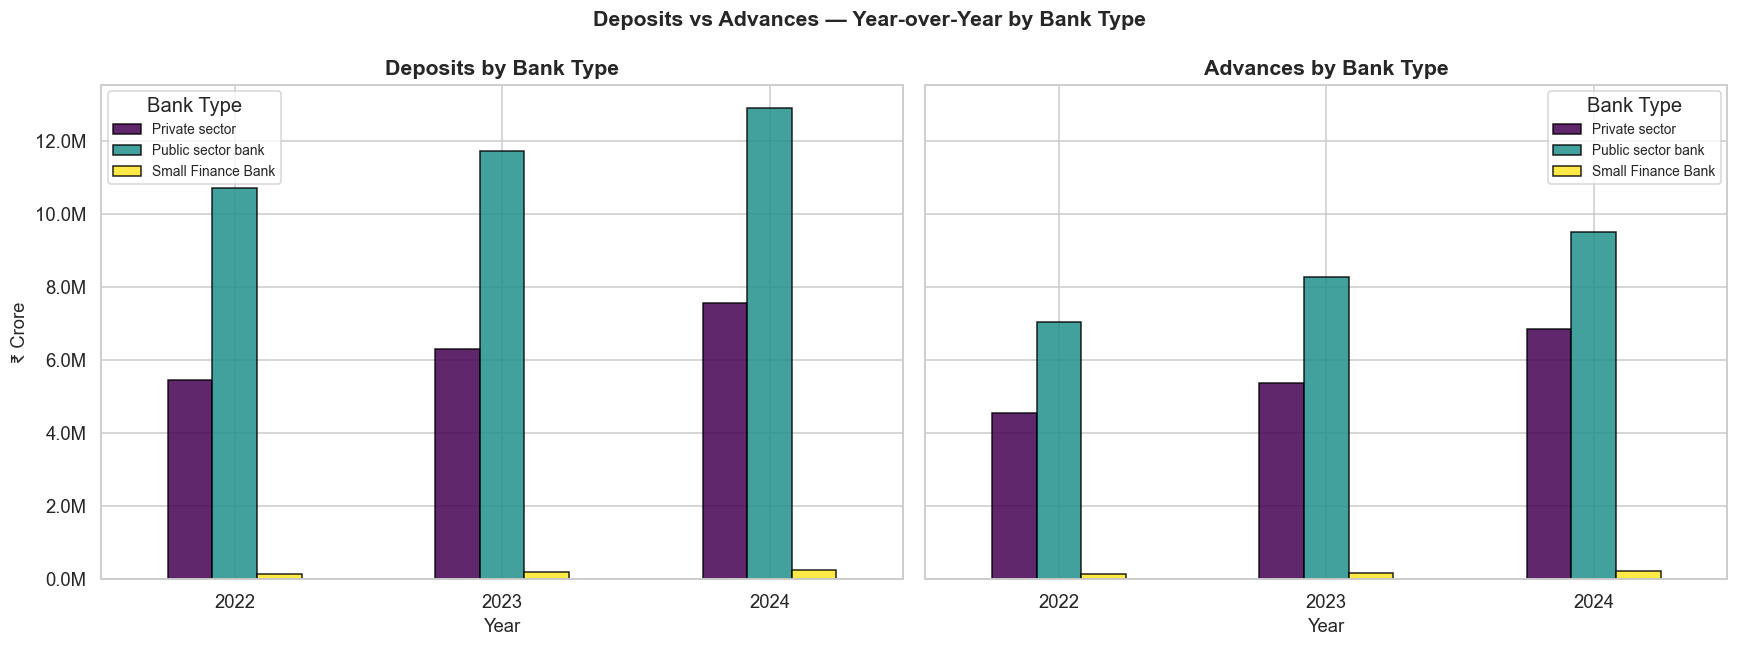

In [7]:
# ─── CELL 7 — Matplotlib: Grouped Bar – Deposits vs Advances by Bank Type ──
type_agg = bank_fin.groupby(['Year', 'Bank_Type'])[['Deposits_Cr', 'Advances_Cr']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for i, metric in enumerate(['Deposits_Cr', 'Advances_Cr']):
    pivot = type_agg.pivot(index='Year', columns='Bank_Type', values=metric)
    pivot.plot(kind='bar', ax=axes[i], colormap='viridis', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{metric.replace("_Cr", "")} by Bank Type', fontweight='bold')
    axes[i].set_ylabel('₹ Crore')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[i].legend(title='Bank Type', fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

fig.suptitle('Deposits vs Advances — Year-over-Year by Bank Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ─── CELL 8 — Plotly: Bubble Chart — NPA vs ROA (sized by Total Assets) ─────
fig = px.scatter(
    bank_fin, x='Net_NPA_Pct', y='Return_on_Assets_Pct',
    size='Total_Assets_Cr', color='Bank_Type',
    hover_name='Bank_Name', animation_frame='Year',
    size_max=55, opacity=0.75,
    title='Net NPA % vs Return on Assets % (Bubble = Total Assets)',
    labels={'Net_NPA_Pct': 'Net NPA (%)', 'Return_on_Assets_Pct': 'Return on Assets (%)'},
    template='plotly_dark', height=600)
fig.show()


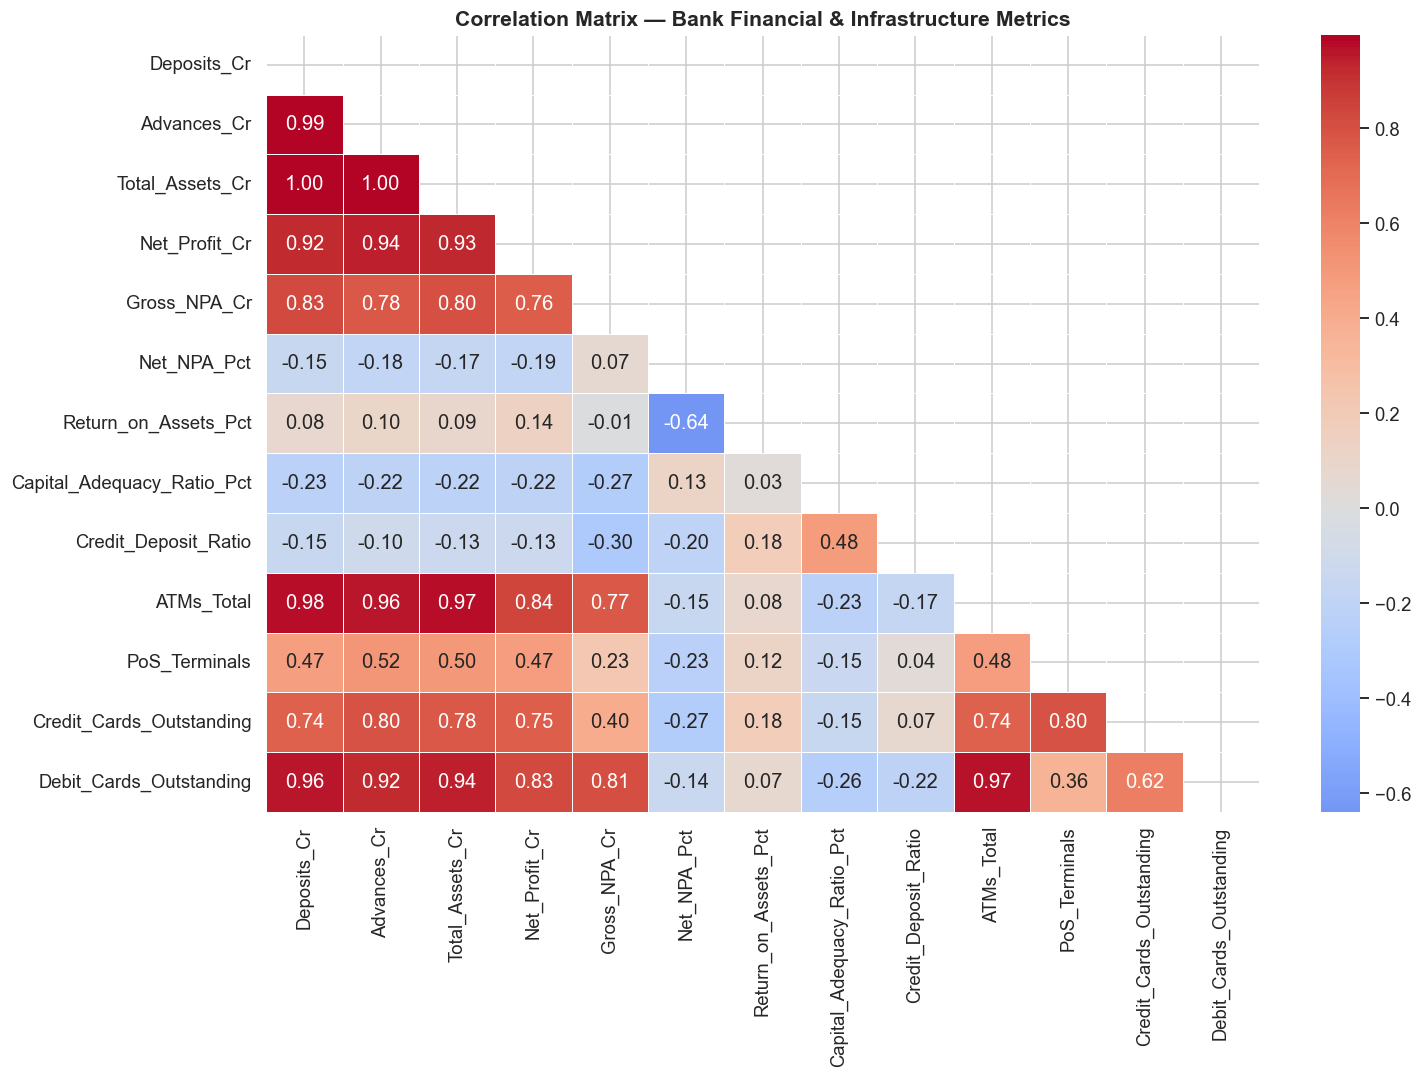

In [9]:
# ─── CELL 9 — Seaborn: Correlation Heatmap — Bank Financial Metrics ─────────
num_cols = ['Deposits_Cr', 'Advances_Cr', 'Total_Assets_Cr', 'Net_Profit_Cr',
            'Gross_NPA_Cr', 'Net_NPA_Pct', 'Return_on_Assets_Pct',
            'Capital_Adequacy_Ratio_Pct', 'Credit_Deposit_Ratio',
            'ATMs_Total', 'PoS_Terminals', 'Credit_Cards_Outstanding',
            'Debit_Cards_Outstanding']
corr = bank_fin[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Bank Financial & Infrastructure Metrics', fontweight='bold')
plt.tight_layout()
plt.show()


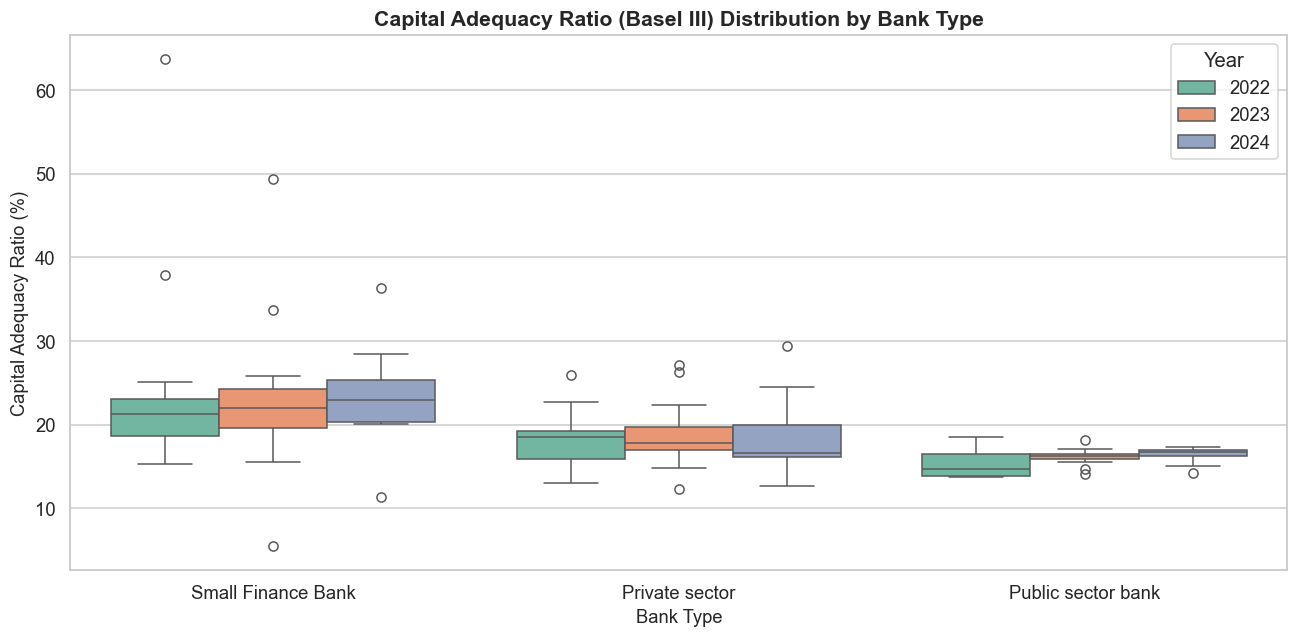

In [10]:
# ─── CELL 10 — Seaborn: Box Plot — Capital Adequacy Ratio by Bank Type ──────
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=bank_fin, x='Bank_Type', y='Capital_Adequacy_Ratio_Pct',
            hue='Year', palette='Set2', ax=ax)
ax.set_title('Capital Adequacy Ratio (Basel III) Distribution by Bank Type', fontweight='bold')
ax.set_xlabel('Bank Type')
ax.set_ylabel('Capital Adequacy Ratio (%)')
plt.tight_layout()
plt.show()


In [11]:
# ─── CELL 11 — Plotly: Treemap — ATM Distribution by Bank Type & Bank ───────
latest_atm = bank_fin[bank_fin['Year'] == bank_fin['Year'].max()].dropna(subset=['ATMs_Total'])
latest_atm = latest_atm[latest_atm['ATMs_Total'] > 0]

fig = px.treemap(
    latest_atm, path=['Bank_Type', 'Bank_Name'], values='ATMs_Total',
    color='ATMs_Total', color_continuous_scale='Viridis',
    title='ATM Distribution — Treemap by Bank Type & Bank',
    height=650)
fig.update_layout(template='plotly_dark')
fig.show()


In [12]:
# ─── CELL 12 — Plotly: Sunburst — Digital Infrastructure Share ──────────────
infra_cols = ['ATMs_Total', 'PoS_Terminals', 'Micro_ATMs', 'UPI_QR_Codes',
              'Credit_Cards_Outstanding', 'Debit_Cards_Outstanding']
infra_melt = latest_atm.melt(
    id_vars=['Bank_Type', 'Bank_Name'], value_vars=infra_cols,
    var_name='Infrastructure', value_name='Count')
infra_melt = infra_melt[infra_melt['Count'] > 0]

fig = px.sunburst(
    infra_melt, path=['Bank_Type', 'Infrastructure'], values='Count',
    color='Infrastructure', title='Digital & Physical Infrastructure — Sunburst',
    height=650)
fig.update_layout(template='plotly_dark')
fig.show()


In [13]:
# ─── CELL 13 — Plotly: Radar Chart — Top 5 Bank Comparison ──────────────────
radar_metrics = ['Return_on_Assets_Pct', 'Capital_Adequacy_Ratio_Pct',
                 'Credit_Deposit_Ratio', 'Net_NPA_Pct',
                 'Business_Per_Employee_Cr', 'Profit_Per_Employee_Lakh']
top5 = latest.nlargest(5, 'Total_Assets_Cr')

# Min-max normalize each metric across the top-5 subset (0-1) so radically
# different units/scales (e.g. Cr vs %) can be compared on one radial axis.
top5_norm = top5[['Bank_Name'] + radar_metrics].copy()
for m in radar_metrics:
    lo, hi = top5_norm[m].min(), top5_norm[m].max()
    top5_norm[m] = 0.5 if hi == lo else (top5_norm[m] - lo) / (hi - lo)

fig = go.Figure()
for _, row in top5_norm.iterrows():
    vals = [row[m] for m in radar_metrics]
    fig.add_trace(go.Scatterpolar(r=vals, theta=radar_metrics, fill='toself', name=row['Bank_Name']))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Top 5 Banks — Key Performance Radar (metrics min-max normalized 0–1)',
    template='plotly_dark', height=600)
fig.show()


In [14]:
# ─── CELL 14 — hvPlot: Interactive Stacked Bar — Deposits & Advances by Year ─
bank_fin.groupby(['Year', 'Bank_Type'])[['Deposits_Cr', 'Advances_Cr']].sum().reset_index().hvplot.bar(
    x='Year', y=['Deposits_Cr', 'Advances_Cr'], by='Bank_Type',
    stacked=True, rot=0, width=900, height=450,
    title='Stacked Deposits + Advances by Bank Type & Year',
    ylabel='₹ Crore')


:Bars   [Year,Bank_Type]   (Deposits_Cr)

---
## 💳 Part 3 — Bank Transaction Analysis
Dataset: `bank_transactions_clean.csv` (~1M+ records)


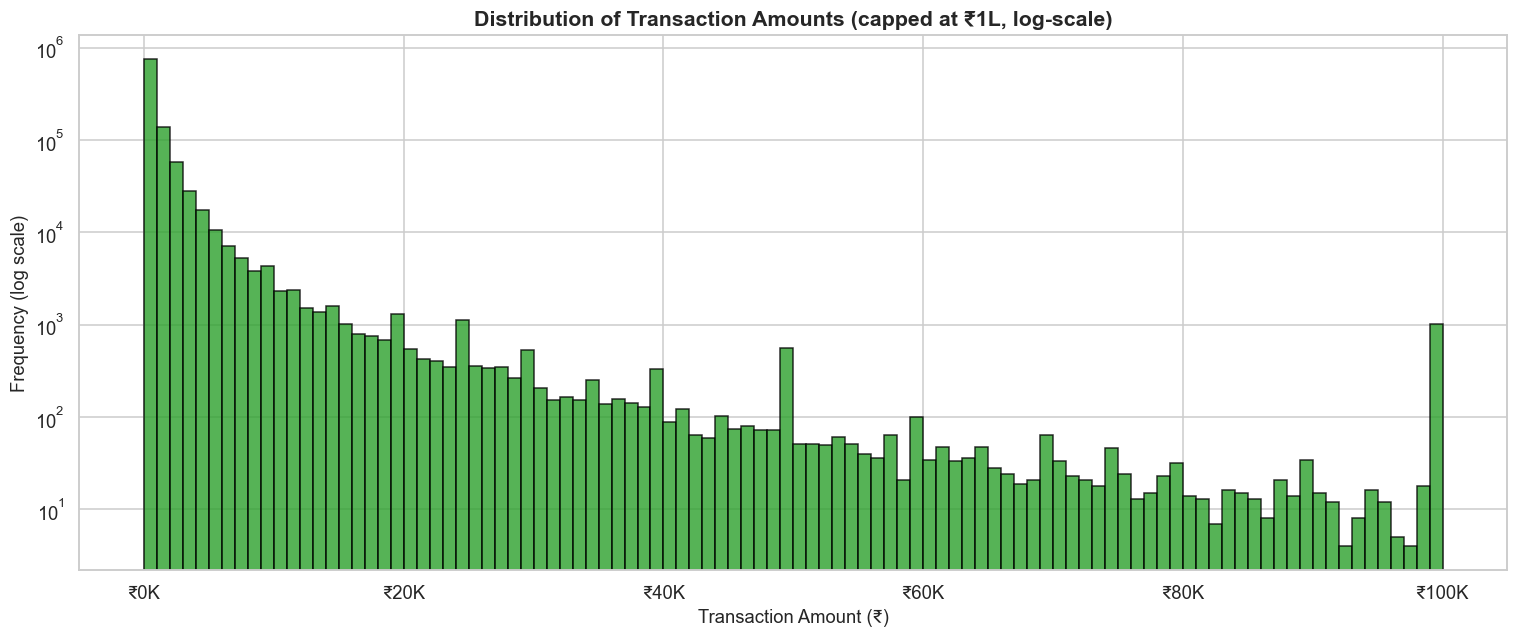

In [15]:
# ─── CELL 15 — Matplotlib: Log-Scale Histogram — Transaction Amounts ────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(txn['TransactionAmount_INR'].clip(upper=100000), bins=100,
        color='#2ca02c', edgecolor='black', alpha=0.8, log=True)
ax.set_title('Distribution of Transaction Amounts (capped at ₹1L, log-scale)', fontweight='bold')
ax.set_xlabel('Transaction Amount (₹)')
ax.set_ylabel('Frequency (log scale)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.show()


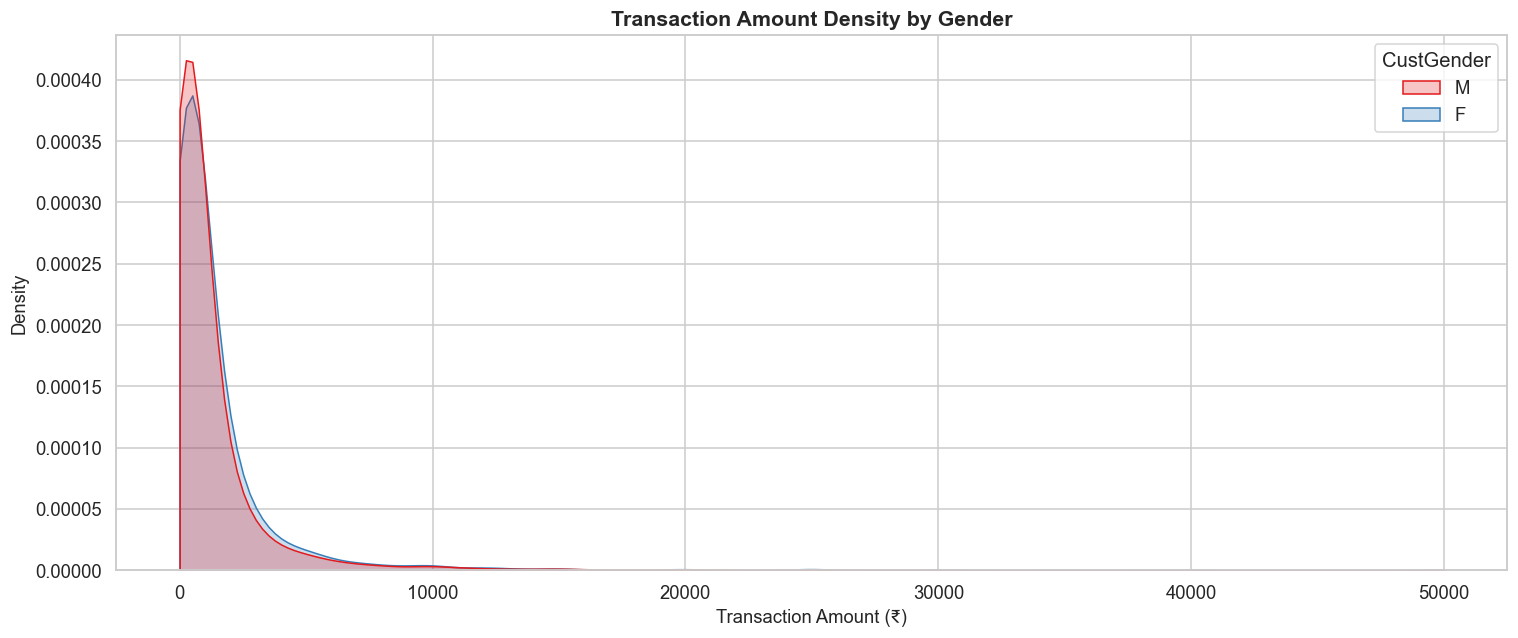

In [16]:
# ─── CELL 16 — Seaborn: KDE — Transaction Amount by Gender ──────────────────
# `sample_txn` is reused by several downstream cells (17, 23) — defined once
# here so re-running cells out of order can't raise a NameError.
sample_txn = txn[txn['CustGender'].isin(['M', 'F'])].sample(n=50000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 6))
sns.kdeplot(data=sample_txn, x='TransactionAmount_INR', hue='CustGender',
            fill=True, common_norm=False, clip=(0, 50000), ax=ax, palette='Set1')
ax.set_title('Transaction Amount Density by Gender', fontweight='bold')
ax.set_xlabel('Transaction Amount (₹)')
plt.tight_layout()
plt.show()


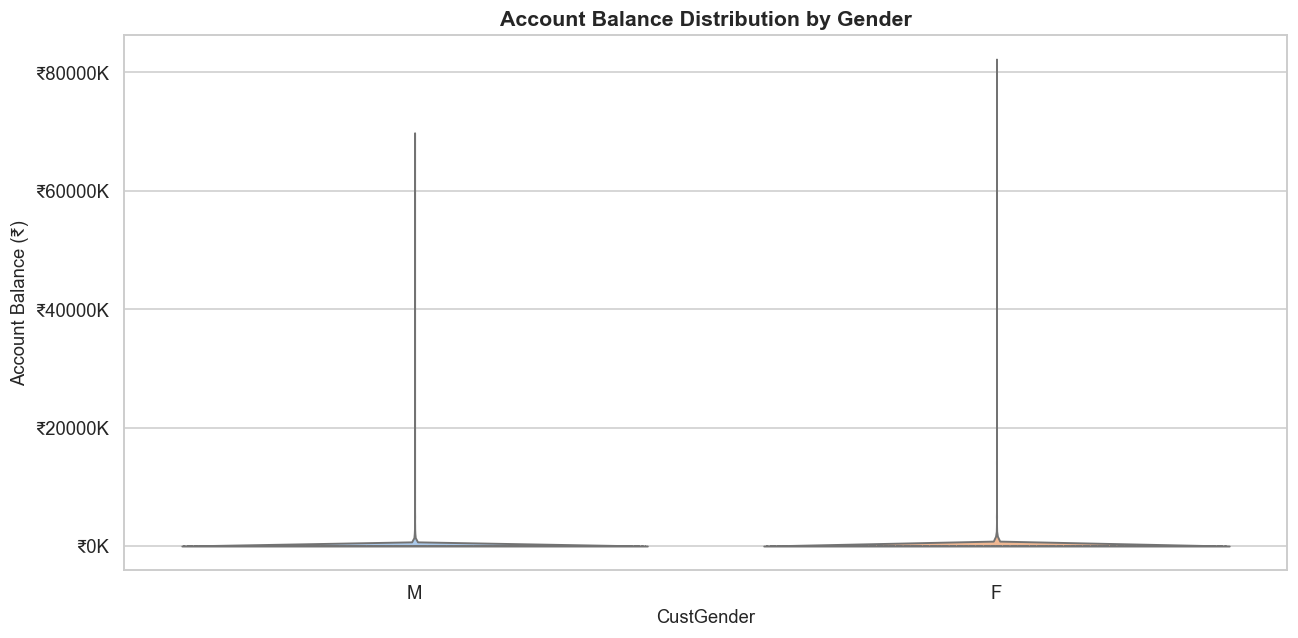

In [17]:
# ─── CELL 17 — Seaborn: Violin Plot — Account Balance by Gender ─────────────
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=sample_txn, x='CustGender', y='CustAccountBalance',
               hue='CustGender', palette='pastel', inner='quartile', ax=ax, cut=0, legend=False)
ax.set_title('Account Balance Distribution by Gender', fontweight='bold')
ax.set_ylabel('Account Balance (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.show()


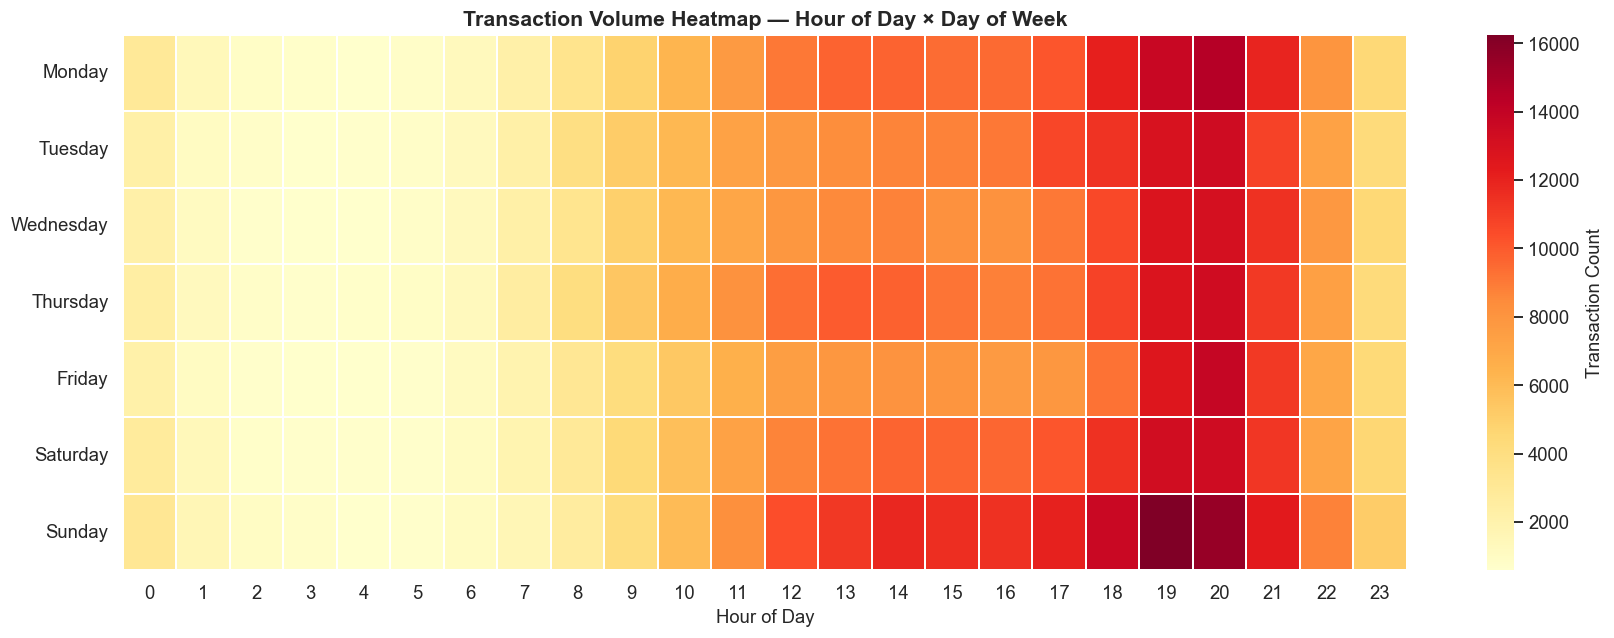

In [18]:
# ─── CELL 18 — Seaborn: Heatmap — Transaction Volume by Hour × Day-of-Week ─
txn['DayOfWeek'] = txn['TransactionDate'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_hw = txn.groupby(['DayOfWeek', 'TransactionHour']).size().reset_index(name='Count')
pivot_hw = pivot_hw.pivot(index='DayOfWeek', columns='TransactionHour', values='Count')
pivot_hw = pivot_hw.reindex(dow_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_hw, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Transaction Count'})
ax.set_title('Transaction Volume Heatmap — Hour of Day × Day of Week', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [19]:
# ─── CELL 19 — Plotly: Horizontal Bar — Top 20 Cities by Transaction Volume ─
city_vol = txn['CustLocation'].value_counts().head(20).reset_index()
city_vol.columns = ['City', 'Transactions']

fig = px.bar(
    city_vol, x='Transactions', y='City', orientation='h',
    color='Transactions', color_continuous_scale='Turbo',
    title='Top 20 Cities by Transaction Volume',
    template='plotly_dark', height=600)
fig.update_layout(yaxis=dict(autorange='reversed'))
fig.show()


In [20]:
# ─── CELL 20 — Plotly: Scatter — Transaction Amount vs Account Balance ──────
# `scatter_sample` is reused by cell 22 (hvPlot scatter) — defined once here.
scatter_sample = txn.sample(n=10000, random_state=42)

fig = px.scatter(
    scatter_sample, x='CustAccountBalance', y='TransactionAmount_INR',
    color='CustGender', opacity=0.5,
    hover_data=['CustLocation', 'TransactionDate'],
    title='Transaction Amount vs Account Balance (10K sample)',
    labels={'CustAccountBalance': 'Account Balance (₹)',
            'TransactionAmount_INR': 'Transaction Amount (₹)'},
    template='plotly_dark', height=550)
fig.show()


In [21]:
# ─── CELL 21 — Plotly: Line — Monthly Transaction Volume & Avg Amount ───────
monthly = txn.groupby('TransactionMonth').agg(
    Volume=('TransactionAmount_INR', 'count'),
    Avg_Amount=('TransactionAmount_INR', 'mean')
).reset_index()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=monthly['TransactionMonth'], y=monthly['Volume'],
                     name='Txn Volume', marker_color='#636EFA', opacity=0.7), secondary_y=False)
fig.add_trace(go.Scatter(x=monthly['TransactionMonth'], y=monthly['Avg_Amount'],
                         name='Avg Amount (₹)', line=dict(color='#EF553B', width=2.5),
                         mode='lines+markers'), secondary_y=True)
fig.update_layout(title='Monthly Transaction Volume & Average Amount',
                  template='plotly_dark', height=500, hovermode='x unified')
fig.update_yaxes(title_text='Volume', secondary_y=False)
fig.update_yaxes(title_text='Avg Txn Amount (₹)', secondary_y=True)
fig.show()


In [22]:
# ─── CELL 22 — hvPlot: Interactive Scatter — Balance vs Amount (by Gender) ──
scatter_sample.hvplot.scatter(
    x='CustAccountBalance', y='TransactionAmount_INR',
    by='CustGender', alpha=0.4, size=30,
    width=900, height=500,
    title='Balance vs Transaction Amount (Interactive)',
    xlabel='Account Balance (₹)', ylabel='Transaction Amount (₹)')


:NdOverlay   [CustGender]
   :Scatter   [CustAccountBalance]   (TransactionAmount_INR)

In [23]:
# ─── CELL 23 — hvPlot: Overlaid Histogram — Transaction Hour by Gender ──────
sample_txn.hvplot.hist(
    'TransactionHour', by='CustGender', alpha=0.6, bins=24,
    width=900, height=400,
    title='Transaction Hour Distribution by Gender',
    xlabel='Hour of Day', ylabel='Frequency')


:NdOverlay   [CustGender]
   :Histogram   [TransactionHour]   (Count)

In [24]:
# ─── CELL 24 — hvPlot: Box Plot — Transaction Amount by Top 10 Cities ───────
top10_cities = txn['CustLocation'].value_counts().head(10).index.tolist()
txn_top10 = txn[txn['CustLocation'].isin(top10_cities)]

txn_top10.hvplot.box(
    y='TransactionAmount_INR', by='CustLocation',
    width=950, height=500, ylim=(0, 50000), rot=45,
    title='Transaction Amount Spread — Top 10 Cities',
    ylabel='Transaction Amount (₹)')


:BoxWhisker   [CustLocation]   (TransactionAmount_INR)

---
## 🔍 Part 4 — State-Level Crime & Socio-Economic Analysis
Dataset: `merged_crime_data.csv`


In [25]:
# ─── CELL 25 — Plotly: Choropleth Map — State-Level Cyber Crime Rate ────────
# Aggregate to state level
state_crime = crime.groupby('State_UT').agg(
    Crime_Rate_Per_100K=('Crime_Rate_Per_100K', 'mean'),
    Cyber_Crimes=('Cyber_Crimes', 'sum'),
    Total_Crimes=('Total_Crimes_Reported', 'sum'),
    Avg_GDP=('GDP_Per_Capita_INR', 'mean'),
    Population=('Population', 'sum'),
    Literacy=('Literacy_Rate_Pct', 'mean'),
).reset_index()

# India state boundaries — loaded from a small, version-controlled local
# GeoJSON (data/geo/india_states.geojson) instead of a remote URL, so the
# map renders reliably offline and isn't at the mercy of link rot (the
# original master notebook's gist URL is now a 404).
import json as _json
with open(INDIA_GEOJSON_PATH, encoding='utf-8') as _f:
    INDIA_GEOJSON = _json.load(_f)

fig = px.choropleth(
    state_crime,
    geojson=INDIA_GEOJSON,
    featureidkey='properties.ST_NM',
    locations='State_UT',
    color='Crime_Rate_Per_100K',
    color_continuous_scale='YlOrRd',
    hover_data=['Cyber_Crimes', 'Total_Crimes', 'Avg_GDP', 'Population'],
    title='India — Average Crime Rate per 100K Population by State',
    height=700)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(template='plotly_dark')
fig.show()


In [26]:
# ─── CELL 26 — Plotly: Choropleth Map — State Cyber Crime Volume ────────────
fig = px.choropleth(
    state_crime,
    geojson=INDIA_GEOJSON,
    featureidkey='properties.ST_NM',
    locations='State_UT',
    color='Cyber_Crimes',
    color_continuous_scale='Plasma',
    hover_data=['Crime_Rate_Per_100K', 'Literacy', 'Avg_GDP'],
    title='India — Total Cyber Crimes by State',
    height=700)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(template='plotly_dark')
fig.show()


In [27]:
# ─── CELL 27 — Plotly: Scatter — GDP per Capita vs Cyber Crimes ─────────────
fig = px.scatter(
    state_crime, x='Avg_GDP', y='Cyber_Crimes',
    size='Population', color='Literacy',
    hover_name='State_UT', size_max=50,
    color_continuous_scale='RdYlGn',
    title='GDP per Capita vs Total Cyber Crimes (Bubble = Population, Color = Literacy)',
    labels={'Avg_GDP': 'Avg GDP per Capita (₹)', 'Cyber_Crimes': 'Total Cyber Crimes'},
    template='plotly_dark', height=600)
fig.show()


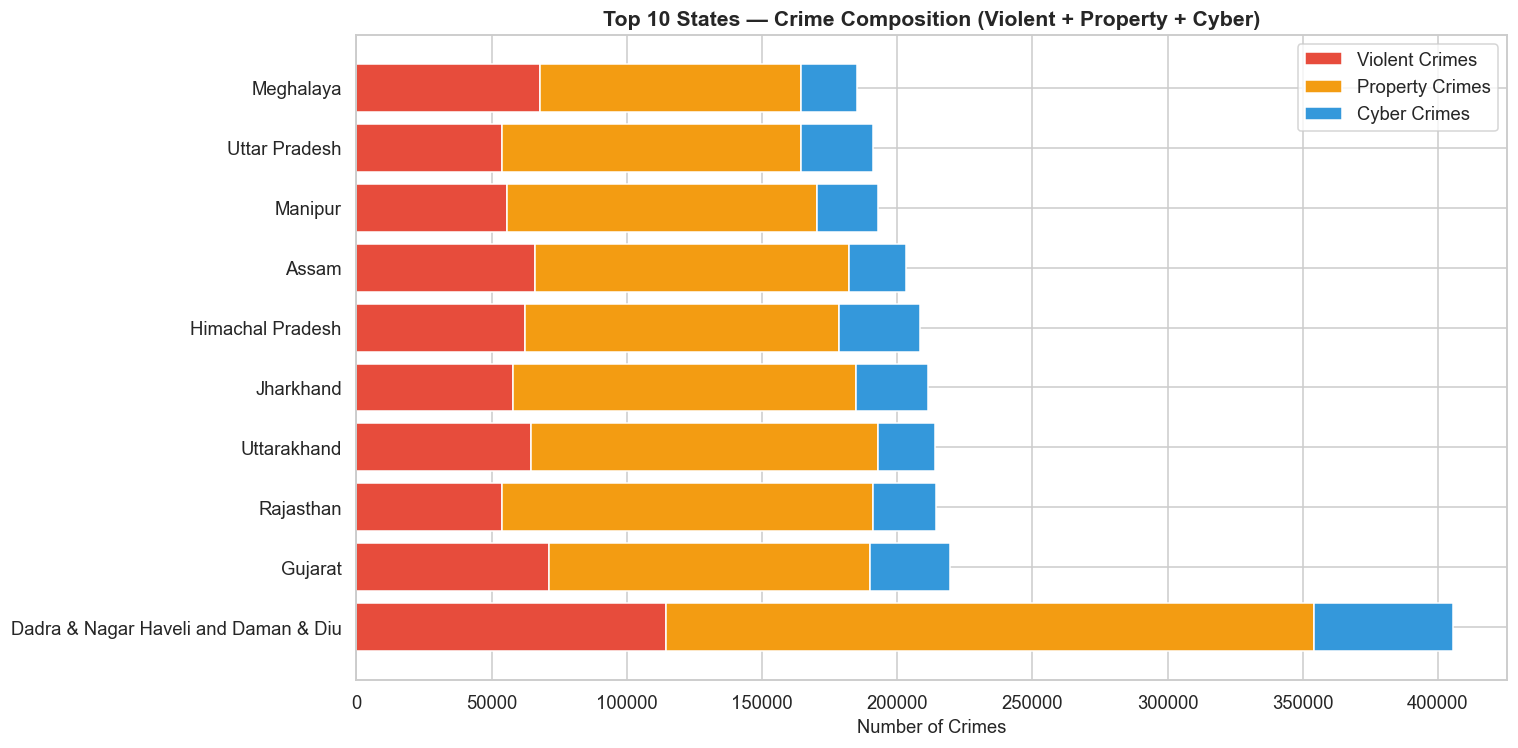

In [28]:
# ─── CELL 28 — Seaborn: Stacked Bar — Crime Breakdown Top 10 States ─────────
top10_states = state_crime.nlargest(10, 'Total_Crimes')

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top10_states))
crime_types = ['Violent_Crimes', 'Property_Crimes', 'Cyber_Crimes']

# Aggregate crime types per state from the original dataset
top10_agg = crime[crime['State_UT'].isin(top10_states['State_UT'])].groupby('State_UT')[crime_types].sum()
top10_agg = top10_agg.reindex(top10_states['State_UT'].values)

colors = ['#e74c3c', '#f39c12', '#3498db']
for i, ctype in enumerate(crime_types):
    ax.barh(top10_agg.index, top10_agg[ctype], left=bottom, label=ctype.replace('_', ' '), color=colors[i])
    bottom += top10_agg[ctype].values

ax.set_title('Top 10 States — Crime Composition (Violent + Property + Cyber)', fontweight='bold')
ax.set_xlabel('Number of Crimes')
ax.legend()
plt.tight_layout()
plt.show()


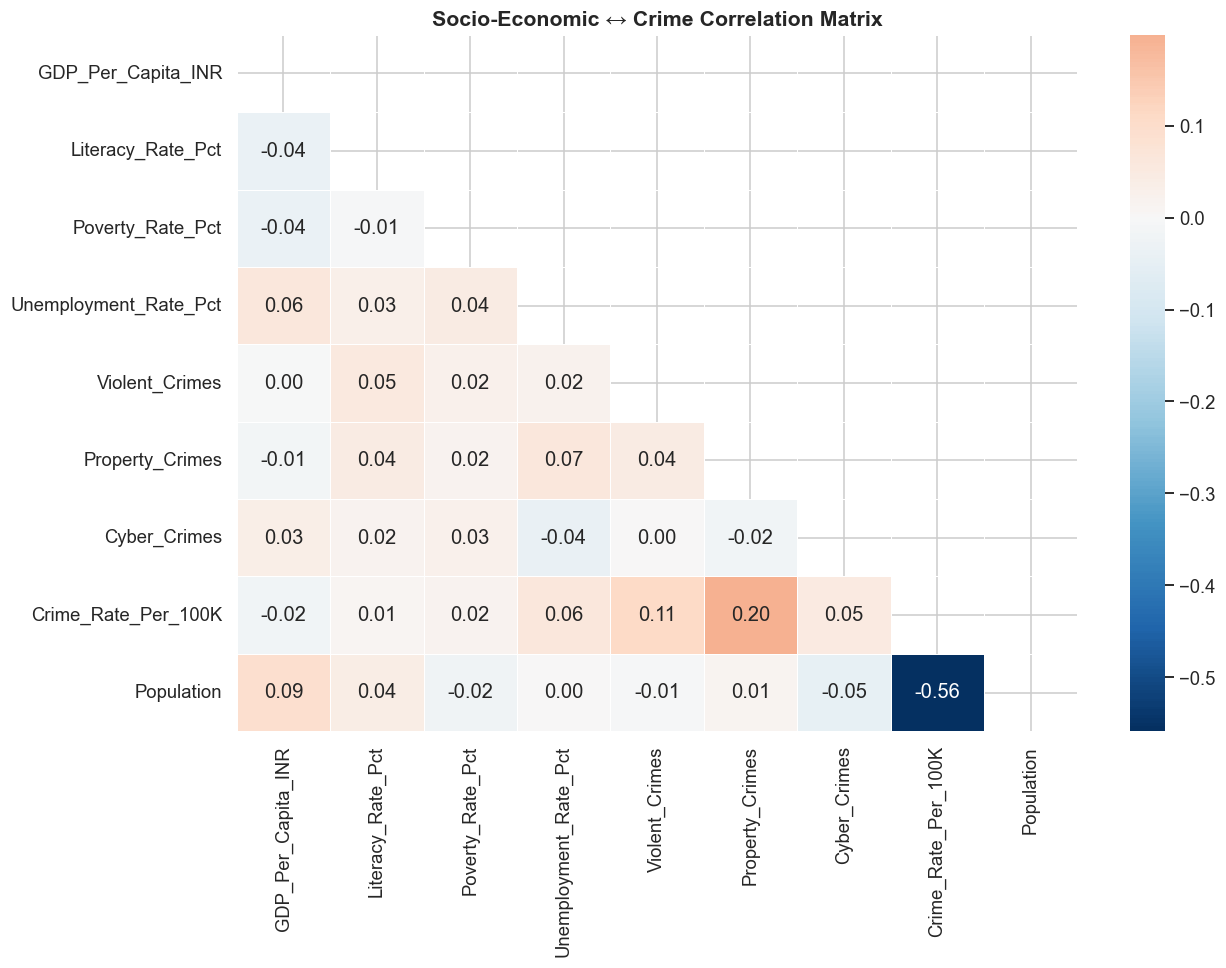

In [29]:
# ─── CELL 29 — Seaborn: Correlation Heatmap — Socioeconomic vs Crime ────────
socio_cols = ['GDP_Per_Capita_INR', 'Literacy_Rate_Pct', 'Poverty_Rate_Pct',
              'Unemployment_Rate_Pct', 'Violent_Crimes', 'Property_Crimes',
              'Cyber_Crimes', 'Crime_Rate_Per_100K', 'Population']
corr_crime = crime[socio_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_crime, dtype=bool))
sns.heatmap(corr_crime, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Socio-Economic ↔ Crime Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


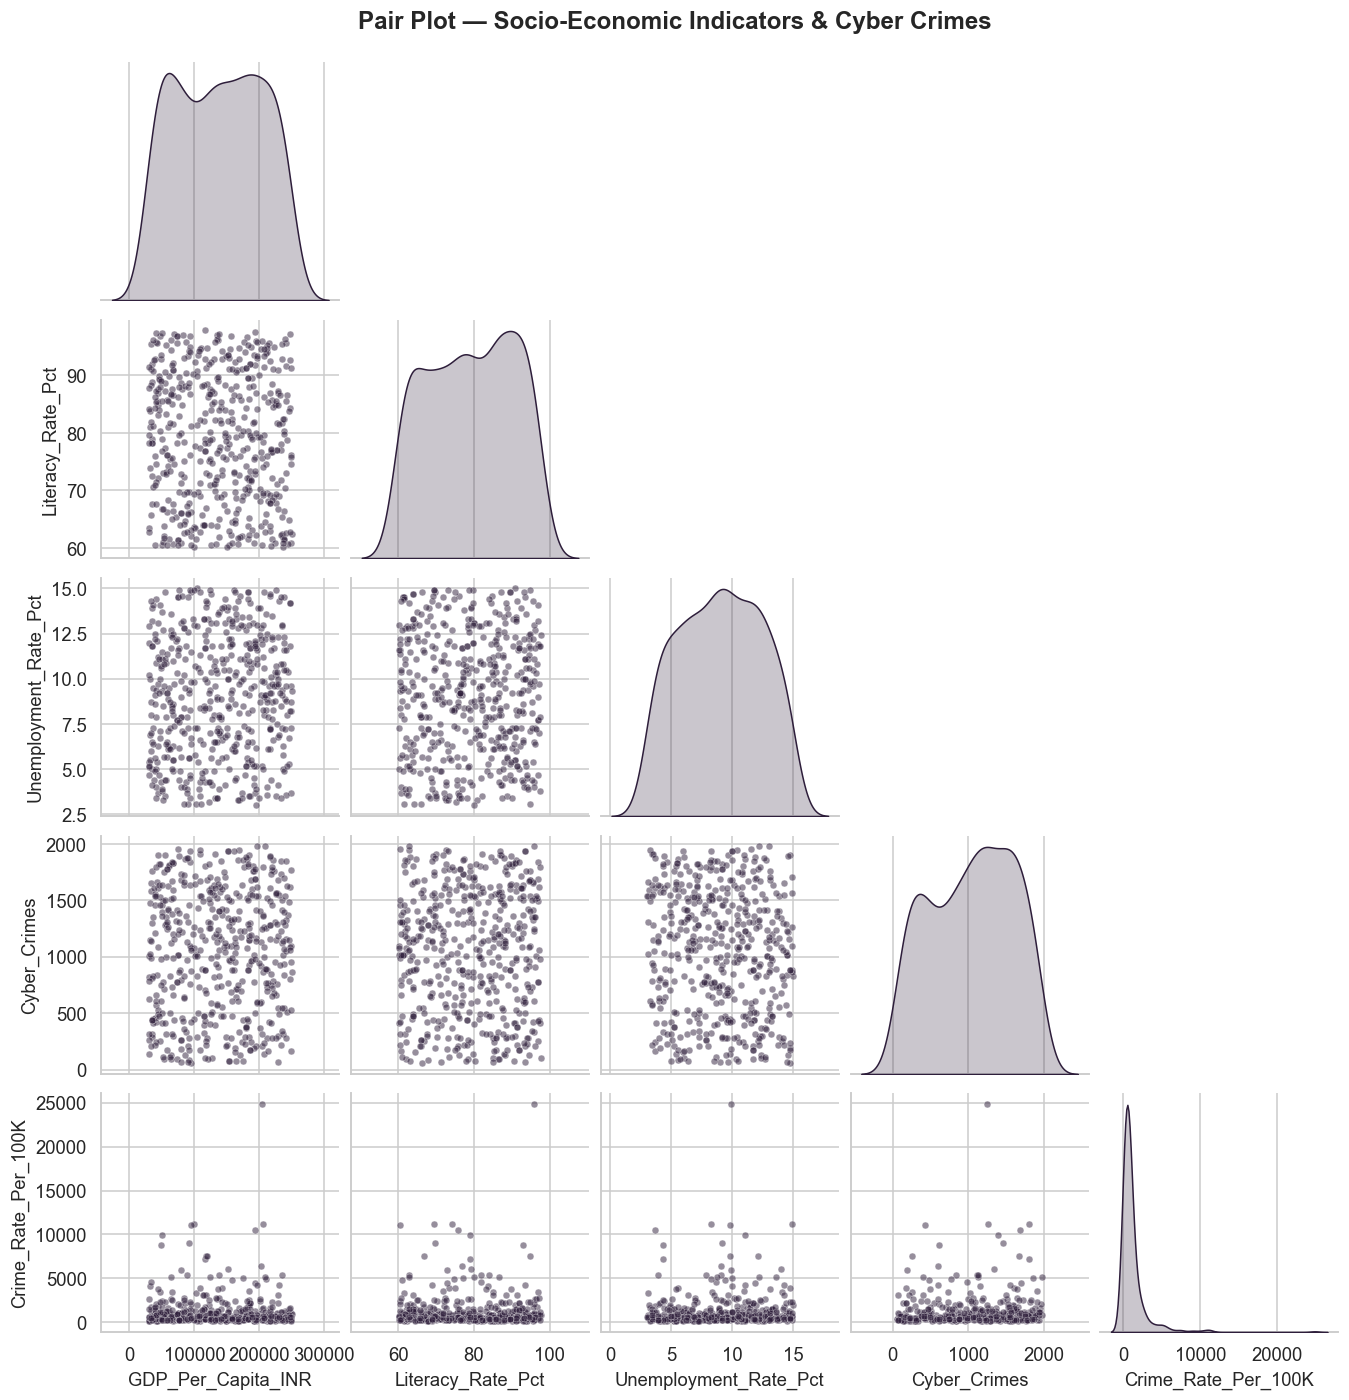

In [30]:
# ─── CELL 30 — Seaborn: Pair Plot — Key Socioeconomic Indicators ────────────
pair_cols = ['GDP_Per_Capita_INR', 'Literacy_Rate_Pct', 'Unemployment_Rate_Pct',
             'Cyber_Crimes', 'Crime_Rate_Per_100K']
pair_sample = crime[pair_cols].dropna().sample(n=min(500, len(crime)), random_state=42)
g = sns.pairplot(pair_sample, corner=True, diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle('Pair Plot — Socio-Economic Indicators & Cyber Crimes', y=1.02, fontweight='bold')
plt.show()


In [31]:
# ─── CELL 31 — hvPlot: Interactive Bar — Cyber Fraud Amounts by State ───────
cyber_fraud = crime.groupby('State_UT')['Cyber_Fraud_Amount_Reported_Lakh'].sum().dropna()
cyber_fraud = cyber_fraud.nlargest(20).reset_index()
cyber_fraud.columns = ['State', 'Fraud_Amount_Lakh']

cyber_fraud.hvplot.barh(
    x='State', y='Fraud_Amount_Lakh',
    color='Fraud_Amount_Lakh', cmap='Reds',
    width=900, height=550,
    title='Top 20 States — Cyber Fraud Amount Reported (₹ Lakh)',
    xlabel='Fraud Amount (₹ Lakh)', ylabel='State')


:Bars   [State]   (Fraud_Amount_Lakh)

In [32]:
# ─── CELL 32 — hvPlot: Interactive Scatter — Poverty vs Crime Rate ──────────
crime.hvplot.scatter(
    x='Poverty_Rate_Pct', y='Crime_Rate_Per_100K',
    c='Cyber_Crimes', cmap='inferno', alpha=0.6, size=50,
    width=900, height=500,
    title='Poverty Rate vs Crime Rate (Color = Cyber Crimes)',
    xlabel='Poverty Rate (%)', ylabel='Crime Rate per 100K')


:Scatter   [Poverty_Rate_Pct]   (Crime_Rate_Per_100K,Cyber_Crimes)

In [33]:
# ─── CELL 33 — Plotly: Parallel Coordinates — Socioeconomic & Crime ─────────
parallel_data = state_crime.dropna(subset=['Avg_GDP', 'Literacy', 'Crime_Rate_Per_100K', 'Cyber_Crimes'])

fig = px.parallel_coordinates(
    parallel_data,
    dimensions=['Avg_GDP', 'Literacy', 'Crime_Rate_Per_100K', 'Cyber_Crimes', 'Population'],
    color='Crime_Rate_Per_100K',
    color_continuous_scale='Turbo',
    title='Parallel Coordinates — State Socioeconomic & Crime Profile',
    height=550)
fig.update_layout(template='plotly_dark')
fig.show()


---
## 🗺️ Part 5 — Geospatial Maps (Folium & PyDeck)
City-level transaction density & state-level crime density mapped onto interactive maps


In [34]:
# ─── CELL 34 — Folium: HeatMap — Transaction Volume by Major Indian Cities ──
# Approximate lat/lon for top Indian cities for mapping
CITY_COORDS = {
    'MUMBAI': (19.076, 72.8777), 'NEW DELHI': (28.6139, 77.209),
    'DELHI': (28.7041, 77.1025), 'BANGALORE': (12.9716, 77.5946),
    'GURGAON': (28.4595, 77.0266), 'NOIDA': (28.5355, 77.391),
    'CHENNAI': (13.0827, 80.2707), 'PUNE': (18.5204, 73.8567),
    'HYDERABAD': (17.385, 78.4867), 'THANE': (19.2183, 72.9781),
    'KOLKATA': (22.5726, 88.3639), 'GHAZIABAD': (28.6692, 77.4538),
    'NAVI MUMBAI': (19.033, 73.0297), 'AHMEDABAD': (23.0225, 72.5714),
    'FARIDABAD': (28.4089, 77.3178), 'JAIPUR': (26.9124, 75.7873),
    'CHANDIGARH': (30.7333, 76.7794), 'LUCKNOW': (26.8467, 80.9462),
    'MOHALI': (30.7046, 76.7179), 'SURAT': (21.1702, 72.8311),
    'INDORE': (22.7196, 75.8577), 'BHOPAL': (23.2599, 77.4126),
    'VADODARA': (22.3072, 73.1812), 'NAGPUR': (21.1458, 79.0882),
    'COIMBATORE': (11.0168, 76.9558), 'PATNA': (25.6093, 85.1376),
    'KOCHI': (9.9312, 76.2673), 'VISAKHAPATNAM': (17.6868, 83.2185),
    'THIRUVANANTHAPURAM': (8.5241, 76.9366), 'JAMSHEDPUR': (22.8046, 86.2029),
}

city_vol_all = txn['CustLocation'].value_counts().head(30).reset_index()
city_vol_all.columns = ['City', 'Count']
city_vol_all['lat'] = city_vol_all['City'].map(lambda c: CITY_COORDS.get(c, (None,))[0])
city_vol_all['lon'] = city_vol_all['City'].map(lambda c: CITY_COORDS.get(c, (None, None))[1])
city_vol_all.dropna(subset=['lat', 'lon'], inplace=True)

m = folium.Map(location=[22.5, 78.9], zoom_start=5, tiles='CartoDB dark_matter')
heat_data = city_vol_all[['lat', 'lon', 'Count']].values.tolist()
HeatMap(heat_data, radius=25, blur=15, max_zoom=10).add_to(m)

# Add circle markers with popups
for _, row in city_vol_all.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(5, row['Count'] / 8000),
        color='#00d4ff', fill=True, fill_opacity=0.7,
        popup=f"<b>{row['City']}</b><br>Transactions: {row['Count']:,}"
    ).add_to(m)

m


In [35]:
# ─── CELL 35 — PyDeck: 3D Column Map — Transaction Volume by City ───────────
# Safe initialization of city_vol_all to avoid NameError if run out of order
if 'city_vol_all' not in globals() or city_vol_all is None or (isinstance(city_vol_all, pd.DataFrame) and city_vol_all.empty):
    CITY_COORDS = {
        'MUMBAI': (19.076, 72.8777), 'NEW DELHI': (28.6139, 77.209),
        'DELHI': (28.7041, 77.1025), 'BANGALORE': (12.9716, 77.5946),
        'GURGAON': (28.4595, 77.0266), 'NOIDA': (28.5355, 77.391),
        'CHENNAI': (13.0827, 80.2707), 'PUNE': (18.5204, 73.8567),
        'HYDERABAD': (17.385, 78.4867), 'THANE': (19.2183, 72.9781),
        'KOLKATA': (22.5726, 88.3639), 'GHAZIABAD': (28.6692, 77.4538),
        'NAVI MUMBAI': (19.033, 73.0297), 'AHMEDABAD': (23.0225, 72.5714),
        'FARIDABAD': (28.4089, 77.3178), 'JAIPUR': (26.9124, 75.7873),
        'CHANDIGARH': (30.7333, 76.7794), 'LUCKNOW': (26.8467, 80.9462),
        'MOHALI': (30.7046, 76.7179), 'SURAT': (21.1702, 72.8311),
        'INDORE': (22.7196, 75.8577), 'BHOPAL': (23.2599, 77.4126),
        'VADODARA': (22.3072, 73.1812), 'NAGPUR': (21.1458, 79.0882),
        'COIMBATORE': (11.0168, 76.9558), 'PATNA': (25.6093, 85.1376),
        'KOCHI': (9.9312, 76.2673), 'VISAKHAPATNAM': (17.6868, 83.2185),
        'THIRUVANANTHAPURAM': (8.5241, 76.9366), 'JAMSHEDPUR': (22.8046, 86.2029),
    }
    city_vol_all = txn['CustLocation'].value_counts().head(30).reset_index()
    city_vol_all.columns = ['City', 'Count']
    city_vol_all['lat'] = city_vol_all['City'].map(lambda c: CITY_COORDS.get(c, (None,))[0])
    city_vol_all['lon'] = city_vol_all['City'].map(lambda c: CITY_COORDS.get(c, (None, None))[1])
    city_vol_all.dropna(subset=['lat', 'lon'], inplace=True)

city_vol_all['elevation'] = city_vol_all['Count'] / 5  # scale for visual

layer = pdk.Layer(
    'ColumnLayer',
    data=city_vol_all,
    get_position=['lon', 'lat'],
    get_elevation='elevation',
    elevation_scale=50,
    radius=30000,
    get_fill_color='[0, 212, 255, 200]',
    pickable=True,
    auto_highlight=True,
)

view_state = pdk.ViewState(
    latitude=22.5, longitude=78.9,
    zoom=4, pitch=45, bearing=0)

r = pdk.Deck(
    layers=[layer], initial_view_state=view_state,
    map_style='mapbox://styles/mapbox/dark-v10',
    tooltip={'text': '{City}\nTransactions: {Count}'})

# Save alongside the notebook (relative path) instead of a hardcoded
# absolute Windows path — portable across OSes and clone locations.
_plots_dir = os.path.join(PROJECT_ROOT, 'data', 'WAREHOUSE', 'plots')
os.makedirs(_plots_dir, exist_ok=True)
_out_path = os.path.join(_plots_dir, 'pydeck_3d_transaction_map.html')
r.to_html(_out_path)
print(f'3D map saved to {_out_path}')
r


3D map saved to d:\Projects\CASHFLOW - COLLEGE\data\WAREHOUSE\plots\pydeck_3d_transaction_map.html


{
  "initialViewState": {
    "bearing": 0,
    "latitude": 22.5,
    "longitude": 78.9,
    "pitch": 45,
    "zoom": 4
  },
  "layers": [
    {
      "@@type": "ColumnLayer",
      "autoHighlight": true,
      "data": [
        {
          "City": "MUMBAI",
          "Count": 103512,
          "elevation": 20702.4,
          "lat": 19.076,
          "lon": 72.8777
        },
        {
          "City": "NEW DELHI",
          "Count": 84834,
          "elevation": 16966.8,
          "lat": 28.6139,
          "lon": 77.209
        },
        {
          "City": "BANGALORE",
          "Count": 81479,
          "elevation": 16295.8,
          "lat": 12.9716,
          "lon": 77.5946
        },
        {
          "City": "GURGAON",
          "Count": 73745,
          "elevation": 14749.0,
          "lat": 28.4595,
          "lon": 77.0266
        },
        {
          "City": "DELHI",
          "Count": 70940,
          "elevation": 14188.0,
          "lat": 28.7041,
          "lon": 77.1025
        },
        {
          "City": "NOIDA",
          "Count": 32753,
          "elevation": 6550.6,
          "lat": 28.5355,
          "lon": 77.391
        },
        {
          "City": "CHENNAI",
          "Count": 29996,
          "elevation": 5999.2,
          "lat": 13.0827,
          "lon": 80.2707
        },
        {
          "City": "PUNE",
          "Count": 25837,
          "elevation": 5167.4,
          "lat": 18.5204,
          "lon": 73.8567
        },
        {
          "City": "HYDERABAD",
          "Count": 23017,
          "elevation": 4603.4,
          "lat": 17.385,
          "lon": 78.4867
        },
        {
          "City": "THANE",
          "Count": 21496,
          "elevation": 4299.2,
          "lat": 19.2183,
          "lon": 72.9781
        },
        {
          "City": "KOLKATA",
          "Count": 19963,
          "elevation": 3992.6,
          "lat": 22.5726,
          "lon": 88.3639
        },
        {
          "City": "GHAZIABAD",
          "Count": 15828,
          "elevation": 3165.6,
          "lat": 28.6692,
          "lon": 77.4538
        },
        {
          "City": "NAVI MUMBAI",
          "Count": 13067,
          "elevation": 2613.4,
          "lat": 19.033,
          "lon": 73.0297
        },
        {
          "City": "AHMEDABAD",
          "Count": 12259,
          "elevation": 2451.8,
          "lat": 23.0225,
          "lon": 72.5714
        },
        {
          "City": "FARIDABAD",
          "Count": 11317,
          "elevation": 2263.4,
          "lat": 28.4089,
          "lon": 77.3178
        },
        {
          "City": "JAIPUR",
          "Count": 9915,
          "elevation": 1983.0,
          "lat": 26.9124,
          "lon": 75.7873
        },
        {
          "City": "CHANDIGARH",
          "Count": 9522,
          "elevation": 1904.4,
          "lat": 30.7333,
          "lon": 76.7794
        },
        {
          "City": "LUCKNOW",
          "Count": 7758,
          "elevation": 1551.6,
          "lat": 26.8467,
          "lon": 80.9462
        },
        {
          "City": "MOHALI",
          "Count": 6736,
          "elevation": 1347.2,
          "lat": 30.7046,
          "lon": 76.7179
        },
        {
          "City": "SURAT",
          "Count": 5762,
          "elevation": 1152.4,
          "lat": 21.1702,
          "lon": 72.8311
        },
        {
          "City": "VISAKHAPATNAM",
          "Count": 4452,
          "elevation": 890.4,
          "lat": 17.6868,
          "lon": 83.2185
        },
        {
          "City": "INDORE",
          "Count": 3889,
          "elevation": 777.8,
          "lat": 22.7196,
          "lon": 75.8577
        },
        {
          "City": "VADODARA",
          "Count": 3887,
          "elevation": 777.4,
          "lat": 22.3072,
          "lon": 73.1812
        },
        {
          "City": "NAGPUR",
          "Count": 3584,
          "elevation": 716.8,
          "lat": 21.1458,
          "lon": 79.0882


In [ ]:
# ─── CELL 36 — Folium: Choropleth — State-Level Crime Rate on India Map ─────
# Uses the same local INDIA_GEOJSON loaded in Cell 25 — no network request,
# so this cell can't fail with the JSONDecodeError the original notebook hit
# when the remote gist URL returned a dead-link error page instead of JSON.
m2 = folium.Map(location=[22.5, 78.9], zoom_start=5, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=INDIA_GEOJSON,
    data=state_crime,
    columns=['State_UT', 'Crime_Rate_Per_100K'],
    key_on='feature.properties.ST_NM',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Crime Rate per 100K',
    nan_fill_color='white'
).add_to(m2)

folium.LayerControl().add_to(m2)
m2


In [ ]:
# ─── CELL 37 — PyDeck: Scatterplot — City Transaction Hotspots ──────────────
scatter_layer = pdk.Layer(
    'ScatterplotLayer',
    data=city_vol_all,
    get_position=['lon', 'lat'],
    get_radius='Count',
    radius_scale=2,
    get_fill_color='[255, 100, 50, 180]',
    pickable=True,
)

r2 = pdk.Deck(
    layers=[scatter_layer],
    initial_view_state=pdk.ViewState(latitude=22.5, longitude=78.9, zoom=4.5, pitch=0),
    map_style='mapbox://styles/mapbox/light-v10',
    tooltip={'text': '{City}\nTransactions: {Count}'})

_out_path2 = os.path.join(PROJECT_ROOT, 'data', 'WAREHOUSE', 'plots', 'pydeck_scatter_hotspots.html')
os.makedirs(os.path.dirname(_out_path2), exist_ok=True)
r2.to_html(_out_path2)
print(f'✅ Scatter map saved to {_out_path2}')
r2


✅ Scatter map saved to d:\Projects\Cashflow\data\WAREHOUSE\plots\pydeck_scatter_hotspots.html


{
  "initialViewState": {
    "latitude": 22.5,
    "longitude": 78.9,
    "pitch": 0,
    "zoom": 4.5
  },
  "layers": [
    {
      "@@type": "ScatterplotLayer",
      "data": [
        {
          "City": "MUMBAI",
          "Count": 103512,
          "elevation": 20702.4,
          "lat": 19.076,
          "lon": 72.8777
        },
        {
          "City": "NEW DELHI",
          "Count": 84834,
          "elevation": 16966.8,
          "lat": 28.6139,
          "lon": 77.209
        },
        {
          "City": "BANGALORE",
          "Count": 81479,
          "elevation": 16295.8,
          "lat": 12.9716,
          "lon": 77.5946
        },
        {
          "City": "GURGAON",
          "Count": 73745,
          "elevation": 14749.0,
          "lat": 28.4595,
          "lon": 77.0266
        },
        {
          "City": "DELHI",
          "Count": 70940,
          "elevation": 14188.0,
          "lat": 28.7041,
          "lon": 77.1025
        },
        {
          "City": "NOIDA",
          "Count": 32753,
          "elevation": 6550.6,
          "lat": 28.5355,
          "lon": 77.391
        },
        {
          "City": "CHENNAI",
          "Count": 29996,
          "elevation": 5999.2,
          "lat": 13.0827,
          "lon": 80.2707
        },
        {
          "City": "PUNE",
          "Count": 25837,
          "elevation": 5167.4,
          "lat": 18.5204,
          "lon": 73.8567
        },
        {
          "City": "HYDERABAD",
          "Count": 23017,
          "elevation": 4603.4,
          "lat": 17.385,
          "lon": 78.4867
        },
        {
          "City": "THANE",
          "Count": 21496,
          "elevation": 4299.2,
          "lat": 19.2183,
          "lon": 72.9781
        },
        {
          "City": "KOLKATA",
          "Count": 19963,
          "elevation": 3992.6,
          "lat": 22.5726,
          "lon": 88.3639
        },
        {
          "City": "GHAZIABAD",
          "Count": 15828,
          "elevation": 3165.6,
          "lat": 28.6692,
          "lon": 77.4538
        },
        {
          "City": "NAVI MUMBAI",
          "Count": 13067,
          "elevation": 2613.4,
          "lat": 19.033,
          "lon": 73.0297
        },
        {
          "City": "AHMEDABAD",
          "Count": 12259,
          "elevation": 2451.8,
          "lat": 23.0225,
          "lon": 72.5714
        },
        {
          "City": "FARIDABAD",
          "Count": 11317,
          "elevation": 2263.4,
          "lat": 28.4089,
          "lon": 77.3178
        },
        {
          "City": "JAIPUR",
          "Count": 9915,
          "elevation": 1983.0,
          "lat": 26.9124,
          "lon": 75.7873
        },
        {
          "City": "CHANDIGARH",
          "Count": 9522,
          "elevation": 1904.4,
          "lat": 30.7333,
          "lon": 76.7794
        },
        {
          "City": "LUCKNOW",
          "Count": 7758,
          "elevation": 1551.6,
          "lat": 26.8467,
          "lon": 80.9462
        },
        {
          "City": "MOHALI",
          "Count": 6736,
          "elevation": 1347.2,
          "lat": 30.7046,
          "lon": 76.7179
        },
        {
          "City": "SURAT",
          "Count": 5762,
          "elevation": 1152.4,
          "lat": 21.1702,
          "lon": 72.8311
        },
        {
          "City": "VISAKHAPATNAM",
          "Count": 4452,
          "elevation": 890.4,
          "lat": 17.6868,
          "lon": 83.2185
        },
        {
          "City": "INDORE",
          "Count": 3889,
          "elevation": 777.8,
          "lat": 22.7196,
          "lon": 75.8577
        },
        {
          "City": "VADODARA",
          "Count": 3887,
          "elevation": 777.4,
          "lat": 22.3072,
          "lon": 73.1812
        },
        {
          "City": "NAGPUR",
          "Count": 3584,
          "elevation": 716.8,
          "lat": 21.1458,
          "lon": 79.0882
        },
        {
          "City": "C

---
## 🧩 Part 6 — PyGWalker: Interactive Tableau-Like Exploration
Drag-and-drop visual exploration for each dataset.

**Note:** These cells are gated behind `ENABLE_HEAVY_CELLS` (see Cell 1) because
PyGWalker renders a heavyweight embedded UI that isn't needed for automated /
headless notebook execution (e.g. CI smoke tests, `nbconvert --execute`). Set
`ENABLE_HEAVY_CELLS=1` in `.env` to render them interactively.


In [ ]:
# ─── CELL 38 — PyGWalker: Bank Financials Explorer ──────────────────────────
if ENABLE_HEAVY_CELLS:
    pyg.walk(bank_fin, env='Jupyter')
else:
    print('Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.')


Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.


In [ ]:
# ─── CELL 39 — PyGWalker: Crime & Socio-Economic Explorer ───────────────────
if ENABLE_HEAVY_CELLS:
    pyg.walk(crime, env='Jupyter')
else:
    print('Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.')


Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.


In [ ]:
# ─── CELL 40 — PyGWalker: Transaction Explorer (50K sample) ─────────────────
if ENABLE_HEAVY_CELLS:
    pyg.walk(txn.sample(n=50000, random_state=42), env='Jupyter')
else:
    print('Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.')


Skipped (ENABLE_HEAVY_CELLS=0). Set ENABLE_HEAVY_CELLS=1 in .env to render this explorer.


---
## 🎨 Part 7 — Advanced Multi-Panel & Cross-Dataset Visuals


In [ ]:
# ─── CELL 41 — Plotly: Animated Scatter — Bank NPA Evolution Over Years ─────
fig = px.scatter(
    bank_fin.dropna(subset=['Net_NPA_Pct', 'Return_on_Assets_Pct', 'Total_Assets_Cr']),
    x='Deposits_Cr', y='Net_Profit_Cr',
    size='Total_Assets_Cr', color='Bank_Type',
    hover_name='Bank_Name', animation_frame='Year',
    size_max=60, opacity=0.8,
    title='Bank Deposits vs Net Profit (Animated by Year)',
    labels={'Deposits_Cr': 'Deposits (₹ Cr)', 'Net_Profit_Cr': 'Net Profit (₹ Cr)'},
    template='plotly_dark', height=600)
fig.show()


In [ ]:
# ─── CELL 42 — Plotly: Funnel — Cyber Fraud Pipeline (Report → Lien → Refund)
fraud_pipeline = crime.groupby('State_UT')[[
    'Cyber_Fraud_Amount_Reported_Lakh',
    'Cyber_Fraud_Lien_Amount_Lakh',
    'Cyber_Fraud_Refunded_Amount_Lakh'
]].sum().sum()

fig = go.Figure(go.Funnel(
    y=['Amount Reported', 'Amount Under Lien', 'Amount Refunded'],
    x=[fraud_pipeline.iloc[0], fraud_pipeline.iloc[1], fraud_pipeline.iloc[2]],
    textinfo='value+percent initial',
    marker=dict(color=['#EF553B', '#FFA15A', '#00CC96'])))
fig.update_layout(
    title='Cyber Fraud Recovery Funnel — National (₹ Lakh)',
    template='plotly_dark', height=450)
fig.show()


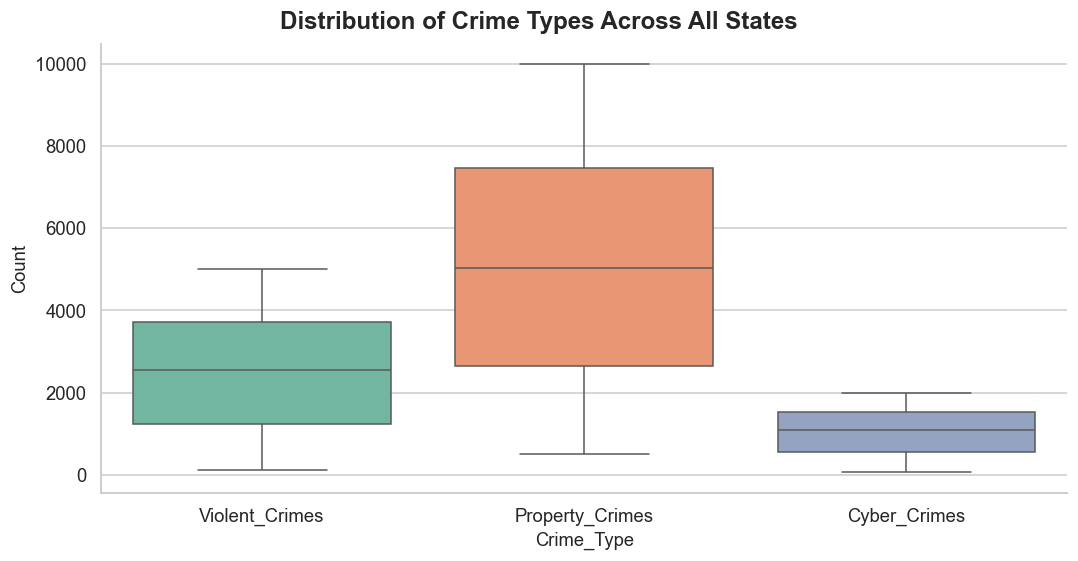

In [ ]:
# ─── CELL 43 — Seaborn: FacetGrid — Crime Type Distributions Across States ──
crime_melted = crime.melt(
    id_vars=['State_UT'],
    value_vars=['Violent_Crimes', 'Property_Crimes', 'Cyber_Crimes'],
    var_name='Crime_Type', value_name='Count')

g = sns.catplot(
    data=crime_melted, x='Crime_Type', y='Count', hue='Crime_Type', kind='box',
    height=5, aspect=2, palette='Set2', legend=False)
g.set_xticklabels(rotation=0)
g.figure.suptitle('Distribution of Crime Types Across All States', y=1.02, fontweight='bold')
plt.show()


In [ ]:
# ─── CELL 44 — Plotly: Donut Charts — Crime Composition & Bank Type Share ───
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]],
                    subplot_titles=['National Crime Composition', 'Bank Assets by Type'])

# Crime composition
crime_totals = crime[['Violent_Crimes', 'Property_Crimes', 'Cyber_Crimes']].sum()
fig.add_trace(go.Pie(
    labels=crime_totals.index, values=crime_totals.values,
    hole=0.45, marker_colors=['#EF553B', '#FFA15A', '#636EFA']), row=1, col=1)

# Bank assets by type
bank_type_assets = latest.groupby('Bank_Type')['Total_Assets_Cr'].sum()
fig.add_trace(go.Pie(
    labels=bank_type_assets.index, values=bank_type_assets.values,
    hole=0.45, marker_colors=['#00CC96', '#AB63FA', '#19D3F3']), row=1, col=2)

fig.update_layout(title='Composition Overview', template='plotly_dark', height=450)
fig.show()


In [ ]:
# ─── CELL 45 — Plotly: Grouped Line — Top 5 Banks ROA & NPA Trend ───────────
top5_names = latest.nlargest(5, 'Total_Assets_Cr')['Bank_Name'].tolist()
top5_ts = bank_fin[bank_fin['Bank_Name'].isin(top5_names)]

fig = make_subplots(rows=1, cols=2, subplot_titles=['Return on Assets (%)', 'Net NPA (%)'])

for name in top5_names:
    sub = top5_ts[top5_ts['Bank_Name'] == name]
    fig.add_trace(go.Scatter(x=sub['Year'], y=sub['Return_on_Assets_Pct'],
                             mode='lines+markers', name=name), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub['Year'], y=sub['Net_NPA_Pct'],
                             mode='lines+markers', name=name, showlegend=False), row=1, col=2)

fig.update_layout(title='Top 5 Banks — ROA & Net NPA Trend', template='plotly_dark', height=450)
fig.show()


In [ ]:
# ─── CELL 46 — Plotly: ECDF — Transaction Amount Distribution ───────────────
ecdf_sample = txn[txn['CustGender'].isin(['M', 'F'])].sample(n=50000, random_state=42)

fig = px.ecdf(
    ecdf_sample, x='TransactionAmount_INR', color='CustGender',
    title='Empirical CDF — Transaction Amount by Gender',
    labels={'TransactionAmount_INR': 'Transaction Amount (₹)'},
    template='plotly_dark', height=500)
fig.update_xaxes(range=[0, 50000])
fig.show()


In [ ]:
# ─── CELL 47 — Plotly: Sankey — Top 5 States Fraud Flow ─────────────────────
top5_fraud = crime.groupby('State_UT')[[
    'Cyber_Fraud_Amount_Reported_Lakh',
    'Cyber_Fraud_Lien_Amount_Lakh',
    'Cyber_Fraud_Refunded_Amount_Lakh'
]].sum().nlargest(5, 'Cyber_Fraud_Amount_Reported_Lakh')

states_list = top5_fraud.index.tolist()
labels = states_list + ['Reported', 'Under Lien', 'Refunded']

source, target, value = [], [], []
for i, state in enumerate(states_list):
    row = top5_fraud.loc[state]
    source.extend([i, i, i])
    target.extend([5, 6, 7])  # Reported, Lien, Refunded
    value.extend([row.iloc[0], row.iloc[1], row.iloc[2]])

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, label=labels,
              color=['#636EFA']*5 + ['#EF553B', '#FFA15A', '#00CC96']),
    link=dict(source=source, target=target, value=value))])
fig.update_layout(title='Cyber Fraud Flow — Top 5 States', template='plotly_dark', height=500)
fig.show()


In [ ]:
# ─── CELL 48 — hvPlot: Interactive Table View — Bank Financials ─────────────
bank_fin.hvplot.table(
    columns=['Bank_Name', 'Year', 'Bank_Type', 'Total_Assets_Cr',
             'Net_Profit_Cr', 'Net_NPA_Pct', 'Return_on_Assets_Pct',
             'ATMs_Total', 'Credit_Cards_Outstanding'],
    width=1100, height=400,
    title='Bank Financials — Interactive Table')


:Table   [Bank_Name,Year,Bank_Type,Total_Assets_Cr,Net_Profit_Cr,Net_NPA_Pct,Return_on_Assets_Pct,ATMs_Total,Credit_Cards_Outstanding]

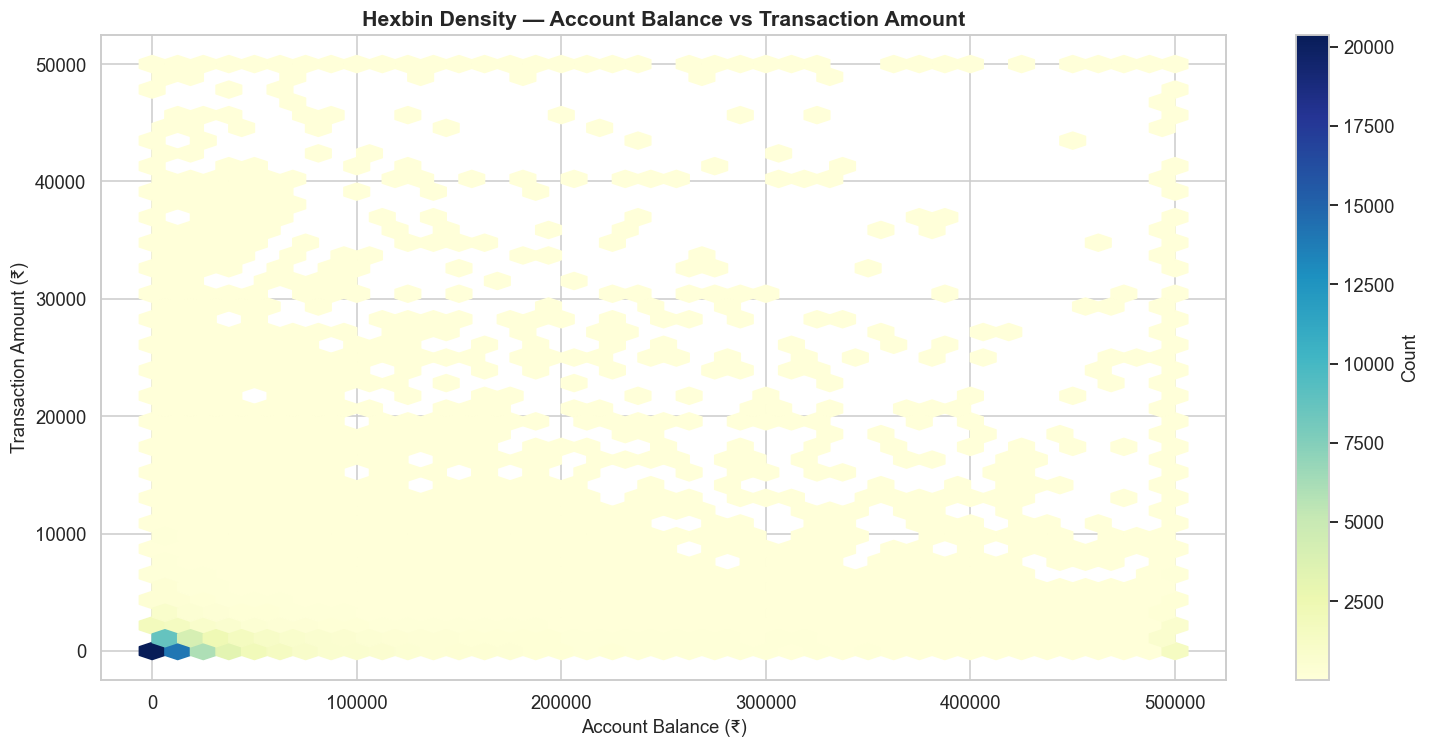

In [ ]:
# ─── CELL 49 — Matplotlib: Hexbin — Balance vs Transaction Amount ───────────
hex_sample = txn.sample(n=100000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 7))
hb = ax.hexbin(
    hex_sample['CustAccountBalance'].clip(upper=500000),
    hex_sample['TransactionAmount_INR'].clip(upper=50000),
    gridsize=40, cmap='YlGnBu', mincnt=1)
cb = fig.colorbar(hb, ax=ax, label='Count')
ax.set_title('Hexbin Density — Account Balance vs Transaction Amount', fontweight='bold')
ax.set_xlabel('Account Balance (₹)')
ax.set_ylabel('Transaction Amount (₹)')
plt.tight_layout()
plt.show()


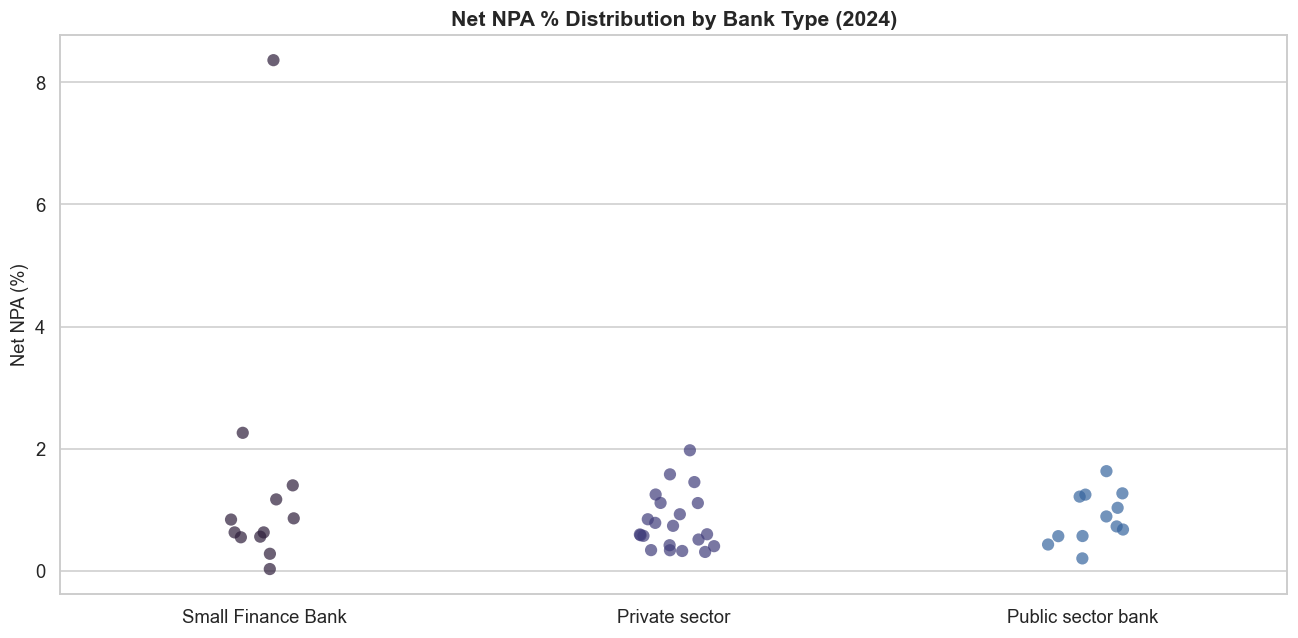

In [ ]:
# ─── CELL 50 — Seaborn: Strip/Swarm — NPA % by Bank Type (Latest Year) ─────
fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(data=latest, x='Bank_Type', y='Net_NPA_Pct',
              hue='Bank_Type', size=8, jitter=True, alpha=0.7, ax=ax, legend=False)
ax.set_title(f'Net NPA % Distribution by Bank Type ({latest["Year"].iloc[0]})', fontweight='bold')
ax.set_ylabel('Net NPA (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


In [ ]:
# ─── CELL 51 — Plotly: Stacked Area — Digital Infra Growth by Bank Type ─────
digi_cols = ['UPI_QR_Codes', 'Credit_Cards_Outstanding', 'Debit_Cards_Outstanding']
digi_agg = bank_fin.groupby(['Year', 'Bank_Type'])[digi_cols].sum().reset_index()
digi_melt = digi_agg.melt(id_vars=['Year', 'Bank_Type'], var_name='Channel', value_name='Count')

fig = px.area(
    digi_melt, x='Year', y='Count', color='Channel',
    facet_col='Bank_Type',
    title='Digital Infrastructure Growth — Cards & UPI QR Codes',
    template='plotly_dark', height=500)
fig.show()


In [ ]:
# ─── CELL 52 — Summary Stats Table ──────────────────────────────────────────
print('='*80)
print('  VISUALIZATION SUMMARY')
print('='*80)
print(f'  Total Cells:          52 (including this one)')
print(f'  Datasets Covered:     4 merged datasets')
print(f'  Chart Libraries Used: matplotlib, seaborn, plotly, hvplot, pydeck, folium, pygwalker')
print(f'  Map Outputs:          2 Folium maps, 2 PyDeck 3D maps, 2 Plotly choropleths')
print(f'  Interactive Explorers: 3 PyGWalker dashboards (gated by ENABLE_HEAVY_CELLS)')
print('='*80)
print('\n✅ Review each cell above and delete any you find unnecessary.')


  VISUALIZATION SUMMARY
  Total Cells:          52 (including this one)
  Datasets Covered:     4 merged datasets
  Chart Libraries Used: matplotlib, seaborn, plotly, hvplot, pydeck, folium, pygwalker
  Map Outputs:          2 Folium maps, 2 PyDeck 3D maps, 2 Plotly choropleths
  Interactive Explorers: 3 PyGWalker dashboards (gated by ENABLE_HEAVY_CELLS)

✅ Review each cell above and delete any you find unnecessary.
